# HOMEWORK 8

In this homework, a machine learning algorithm for automatic document image binarization is implemented. The goal of document binarization is to separate textual content (characters) from the background. This step is essential for automatic document analysis and information extraction.

The Otsu thresholding algorithm is used to determine the optimal global threshold that separates foreground from background based on intensity distribution.

In [184]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

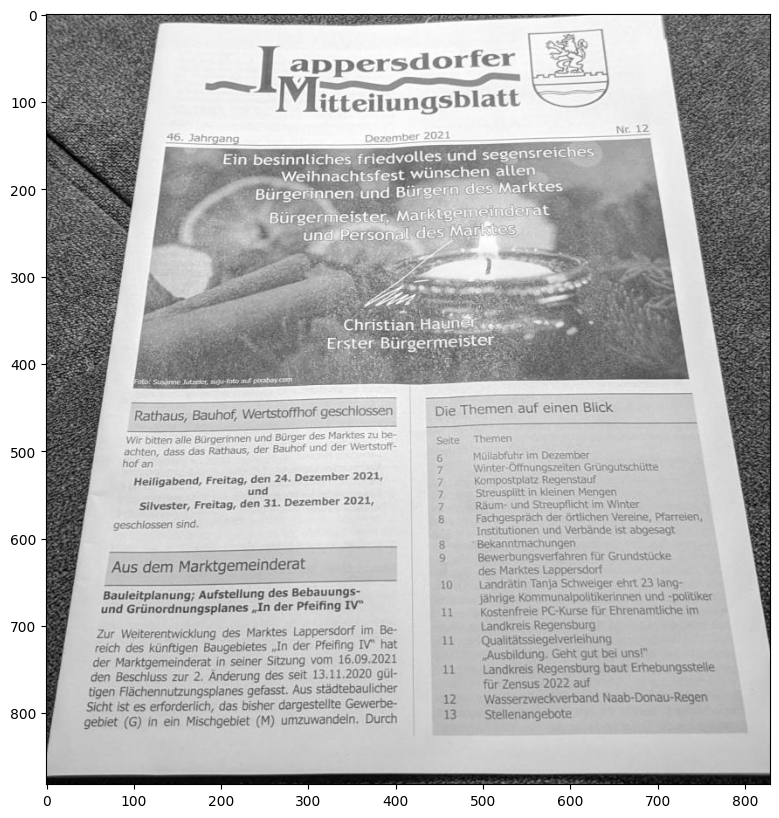

In [185]:
img = cv2.imread('data/document.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')

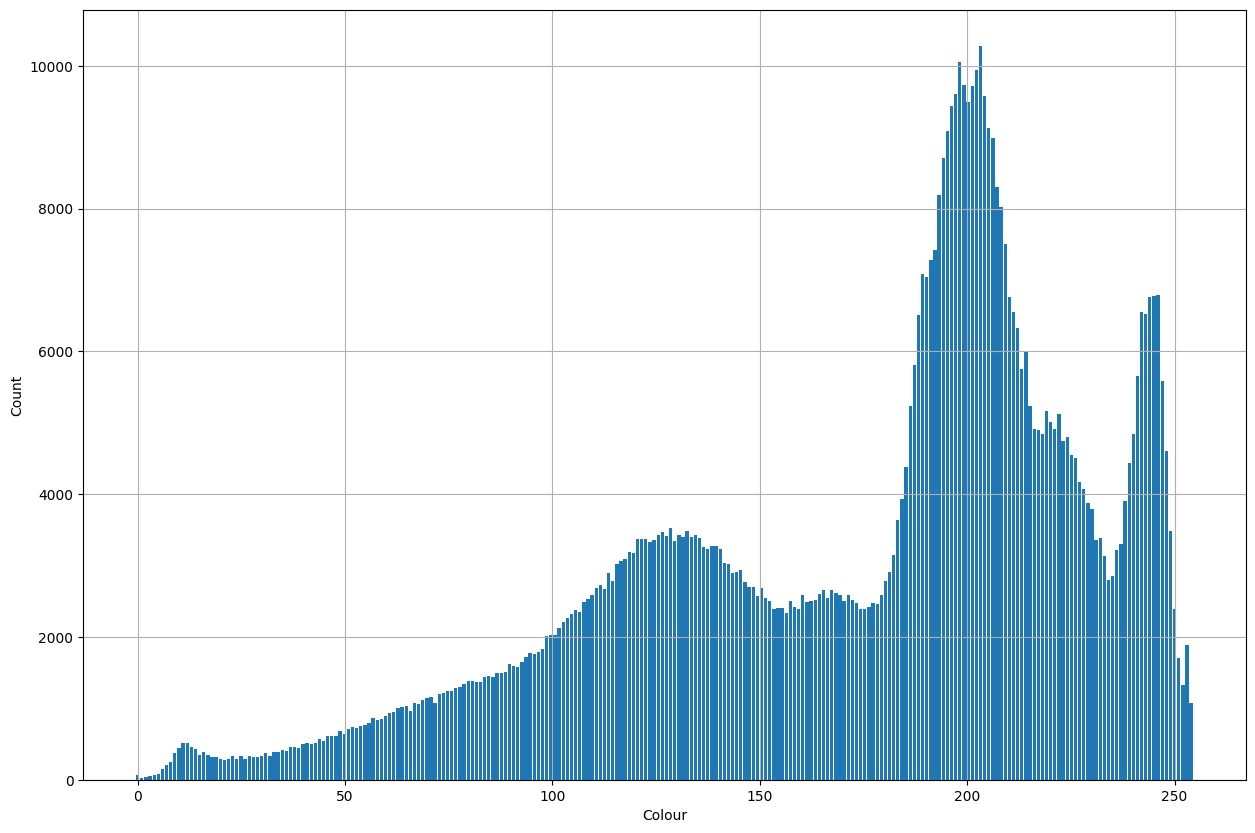

In [186]:
h = np.histogram(img, 256)
plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour'), plt.ylabel('Count')
plt.grid(True)

### Otsu Thresholding

The Otsu algorithm is implemented using a brute-force optimization approach.  
All possible gray-level thresholds (0–255) are evaluated, and for each threshold the within-class variance is computed.  
The optimal threshold is selected as the one that minimizes the weighted sum of foreground and background variances.

In [187]:
rows, cols = img.shape[:2]

num_pixels = rows * cols

# Initializations
best_wcv = 1e6
opt_th = None

for th in range(0, 256):
    foreground = img[img > th].ravel()

    background = img[img <= th].ravel()
    
    if len(foreground) == 0 or len(background) == 0:
        continue

    omega_f = len(foreground) / num_pixels
    omega_b = len(background) / num_pixels
    
    sigma2_f = np.var(foreground)
    sigma2_b = np.var(background)
    
    wcv = omega_f * sigma2_f + omega_b * sigma2_b
    
    if wcv < best_wcv:
        best_wcv = wcv
        opt_th = th
        
print('Optimal threshold', opt_th)

Optimal threshold 159


(<Axes: >, <matplotlib.image.AxesImage at 0x7c6c87482f00>)

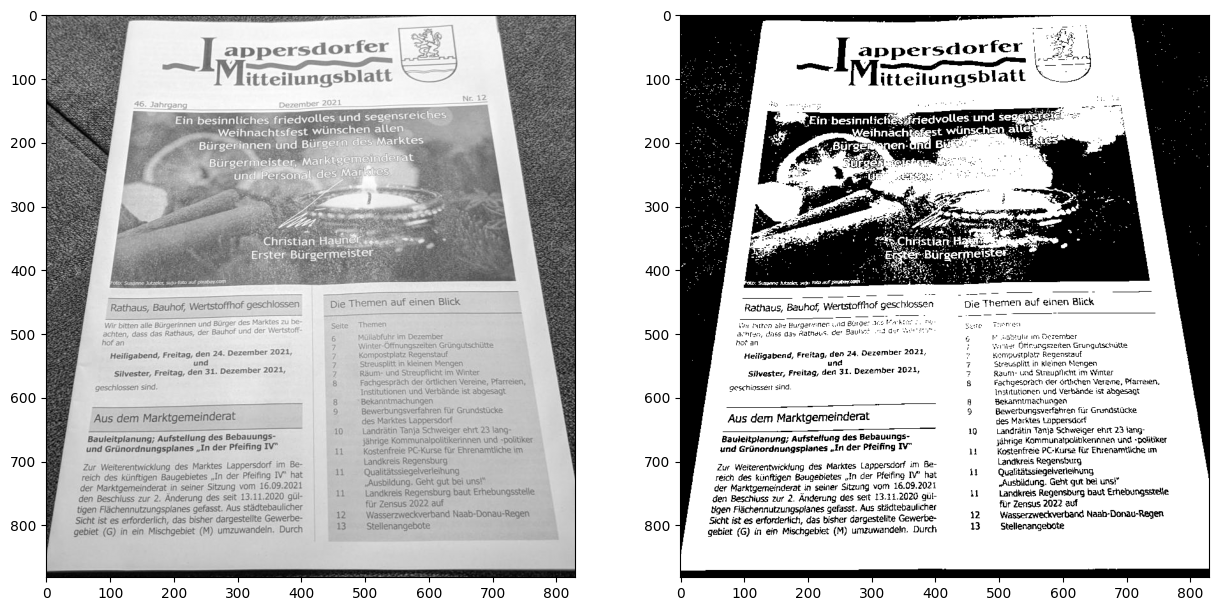

In [188]:
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.subplot(122), plt.imshow(img > opt_th, cmap='gray')

### OpenCV Otsu

In [189]:
ret, binary_cv = cv2.threshold(
    img, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold (custom implementation):", opt_th)
print("OpenCV Otsu threshold:", ret)

Otsu threshold (custom implementation): 159
OpenCV Otsu threshold: 159.0


Both methods produce identical threshold values. This confirms that the brute-force implementation correctly reproduces the behavior of OpenCV’s optimized Otsu algorithm. 

In [ ]:
def plot_otsu_analysis(img, opt_th):
    
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    rows, cols = img.shape[:2]
    num_pixels = rows * cols

    foreground = img[img > opt_th]
    background = img[img <= opt_th]

    omega_f = len(foreground) / num_pixels
    omega_b = len(background) / num_pixels

    mu_f = np.mean(foreground)
    mu_b = np.mean(background)

    sigma_between = omega_f * omega_b * (mu_f - mu_b) ** 2
    sigma_total = np.var(img)
    eta = sigma_between / sigma_total

    plt.figure(figsize=(10,5))

    plt.hist(background, bins=256, range=(0,256),
             color='skyblue', alpha=0.7, label='Background')

    plt.hist(foreground, bins=256, range=(0,256),
             color='orange', alpha=0.7, label='Foreground')

    plt.axvline(opt_th, color='red', linestyle='--',
                linewidth=2, label=f'Otsu Threshold = {opt_th}')

    plt.axvline(mu_b, color='lightblue', linestyle=':',
                linewidth=2, label=f'μ_background = {mu_b:.1f}')

    plt.axvline(mu_f, color='darkorange', linestyle=':',
                linewidth=2, label=f'μ_foreground = {mu_f:.1f}')

    plt.title(f"Otsu Analysis | Separability η = {eta:.3f}")
    plt.xlabel("Intensity")
    plt.ylabel("Pixel Count")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Otsu threshold: {opt_th}")
    print(f"Separability η: {eta:.4f}")

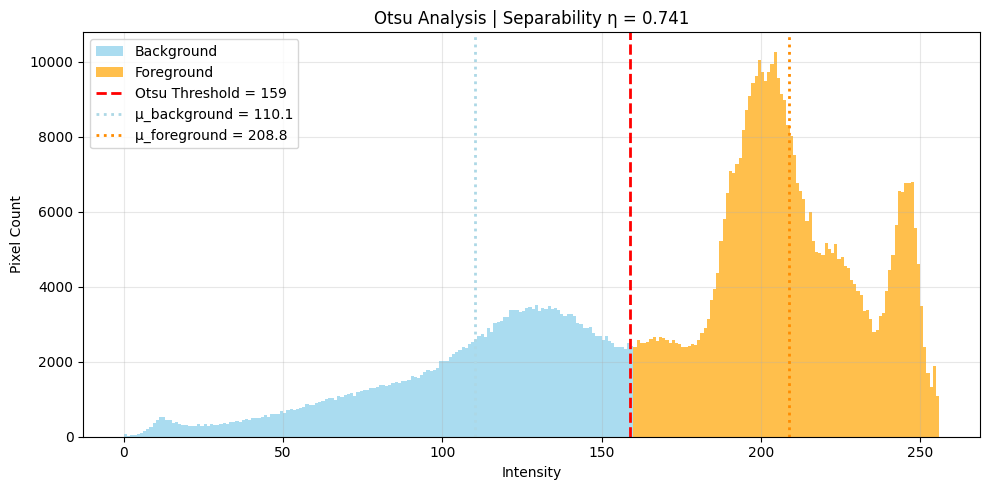

Otsu threshold: 159
Separability η: 0.7406


In [197]:
plot_otsu_analysis(img, opt_th)

# Questions

### 1. Looking at the computed histogram, could it be considered bimodal?

Yes, the histogram can be considered approximately bimodal.

Two dominant intensity regions are clearly visible:

- A peak located at lower intensity values, corresponding to text and darker image regions.

- A peak located at higher intensity values, corresponding to the paper background.

Although the peaks partially overlap and are not perfectly separated, there is a noticeable valley between them around intensity ~159. This indicates the presence of two main intensity clusters, satisfying the bimodal assumption required by Otsu’s method.

The separability measure (η ≈ 0.74) further confirms that the two classes are reasonably well separated, though not perfectly distinct.

### 2. Looking at the computed histogram, what binarization threshold would you choose? Why?

A threshold around 155–165 would be appropriate.

This range corresponds to the minimum (valley) between the two dominant peaks in the histogram. Selecting a threshold in this region minimizes the overlap between foreground (text) and background (paper), which directly aligns with Otsu’s objective of minimizing within-class variance.

The automatically computed threshold of 159 lies precisely in this separation region, confirming that the algorithm correctly identified the optimal global threshold.

### 3. Looking at the resulting (thresholded) image, is the text binarization (detection) good?

The text binarization is generally good.

Most characters are clearly separated from the background and appear as distinct dark regions. The majority of the textual content is preserved and readable.

However, some minor imperfections can be observed:

- Small noisy regions in darker image areas,

- Slight loss of detail in textured or shaded regions,

- Possible artifacts caused by non-uniform illumination.

Since Otsu performs global thresholding, it cannot compensate for local intensity variations or shadows. Nevertheless, given the separability value (η ≈ 0.74), the binarization quality is satisfactory and appropriate for document analysis purposes.

Overall, the results confirm that Otsu thresholding is suitable for this image, as the foreground and background intensity distributions are sufficiently distinct.

# Experimental Evaluation of Otsu Thresholding

Shape: (380, 570, 3)


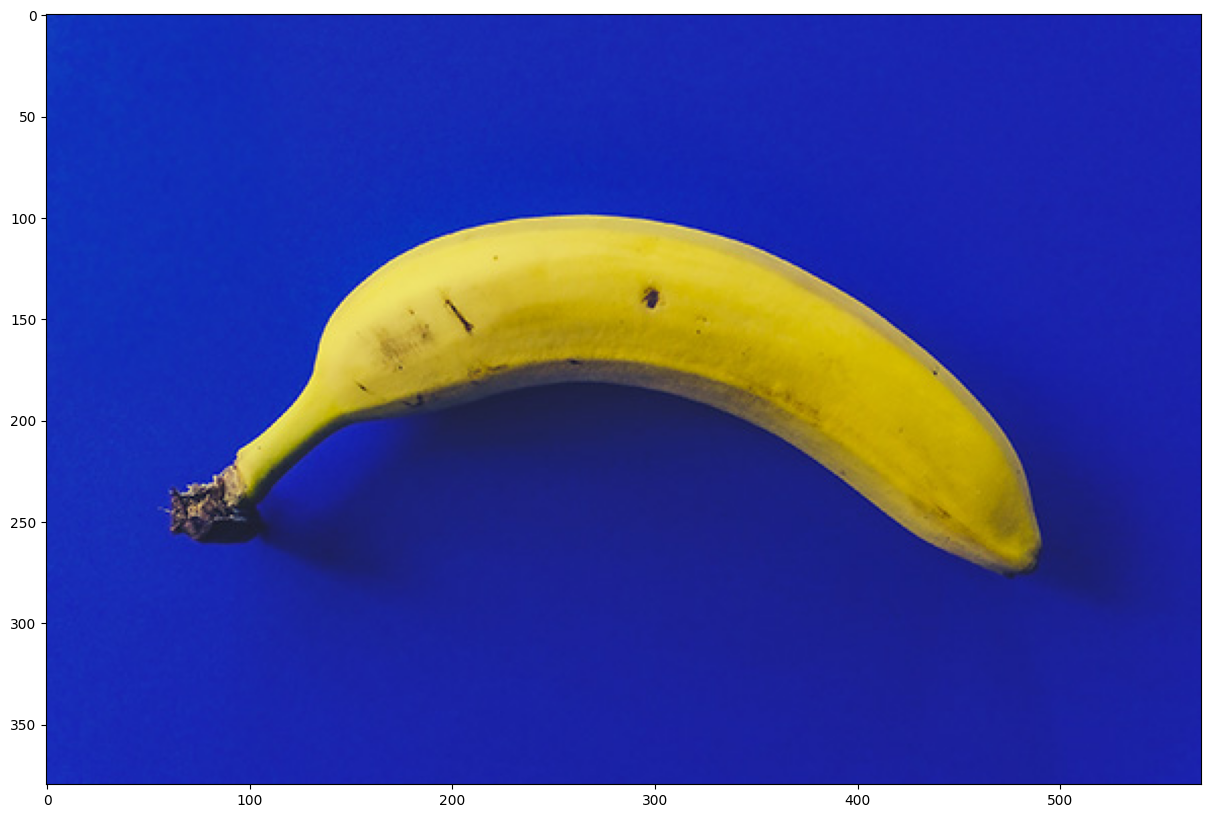

In [203]:
img2 = cv2.imread('data/6.jpg')
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
print(f'Shape: {img2_rgb.shape}')
plt.imshow(img2_rgb)

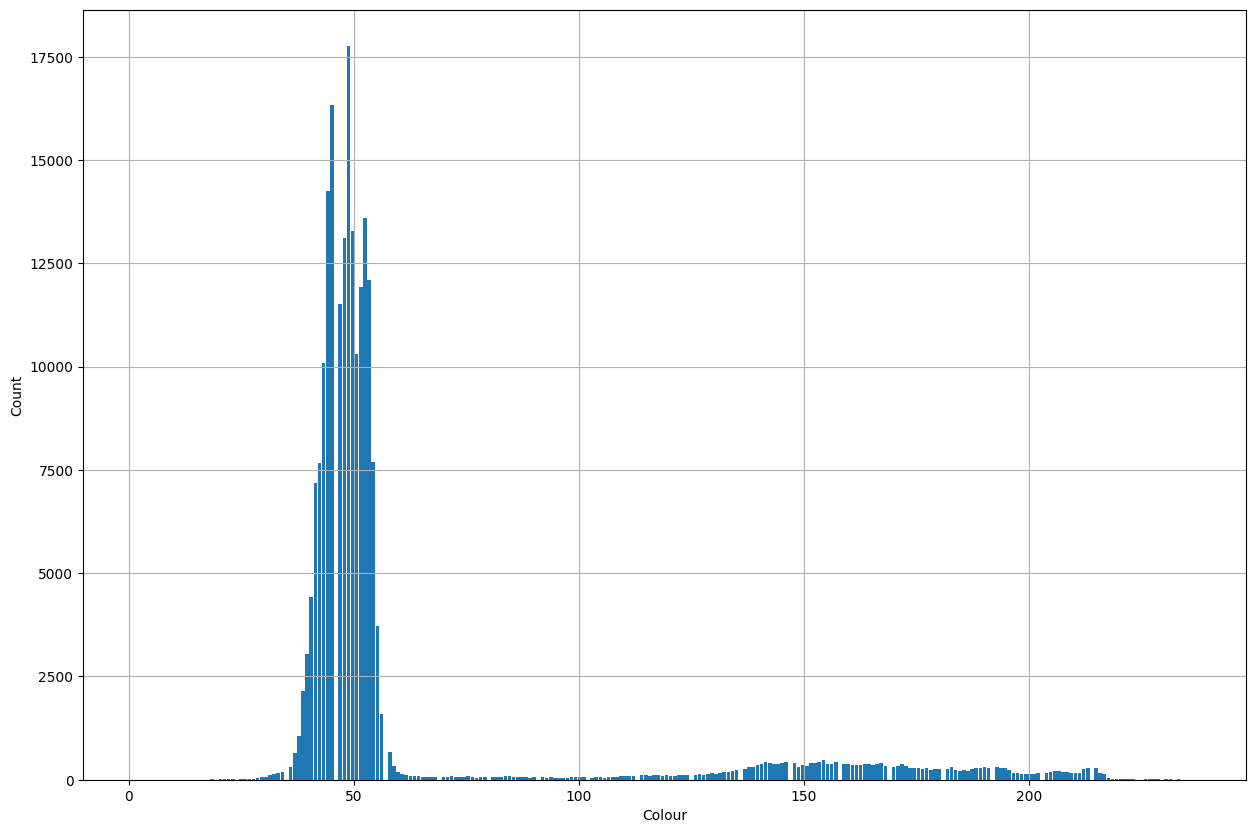

In [204]:
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

h = np.histogram(img2, 256)
plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour'), plt.ylabel('Count')
plt.grid(True)

In [206]:
def otsu_threshold_bruteforce(img, return_binary=False, invert=False):
    if img is None:
        raise ValueError("Input image is None.")

    if img.ndim == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img

    if img_gray.dtype != np.uint8:
        if np.issubdtype(img_gray.dtype, np.floating) and img_gray.max() <= 1.0:
            img_gray = (img_gray * 255.0).round()
        img_gray = np.clip(img_gray, 0, 255).astype(np.uint8)

    rows, cols = img_gray.shape
    num_pixels = rows * cols

    best_wcv = float("inf")
    opt_th = 0

    for th in range(256):
        fg = img_gray[img_gray > th]
        bg = img_gray[img_gray <= th]

        if fg.size == 0 or bg.size == 0:
            continue

        omega_f = fg.size / num_pixels
        omega_b = bg.size / num_pixels

        sigma2_f = fg.var()
        sigma2_b = bg.var()

        wcv = omega_f * sigma2_f + omega_b * sigma2_b

        if wcv < best_wcv:
            best_wcv = wcv
            opt_th = th

    if not return_binary:
        return opt_th, best_wcv

    if invert:
        binary = (img_gray <= opt_th).astype(np.uint8) * 255
    else:
        binary = (img_gray > opt_th).astype(np.uint8) * 255

    return opt_th, best_wcv, binary

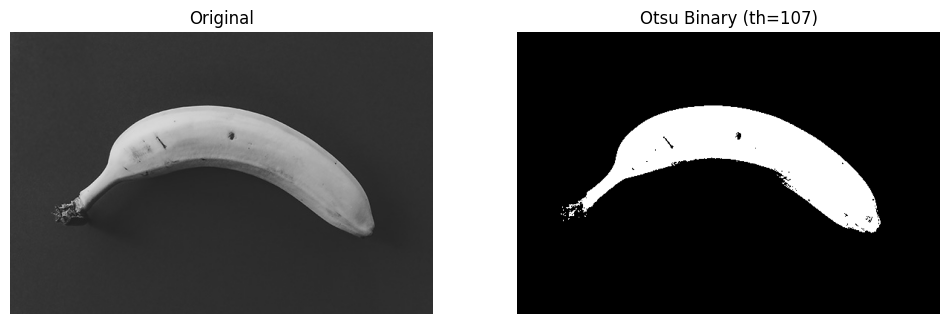

In [207]:
opt_th2, best_wcv2, binary2 = otsu_threshold_bruteforce(img2, return_binary=True)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(binary2, cmap="gray")
plt.title(f"Otsu Binary (th={opt_th2})")
plt.axis("off")
plt.show()

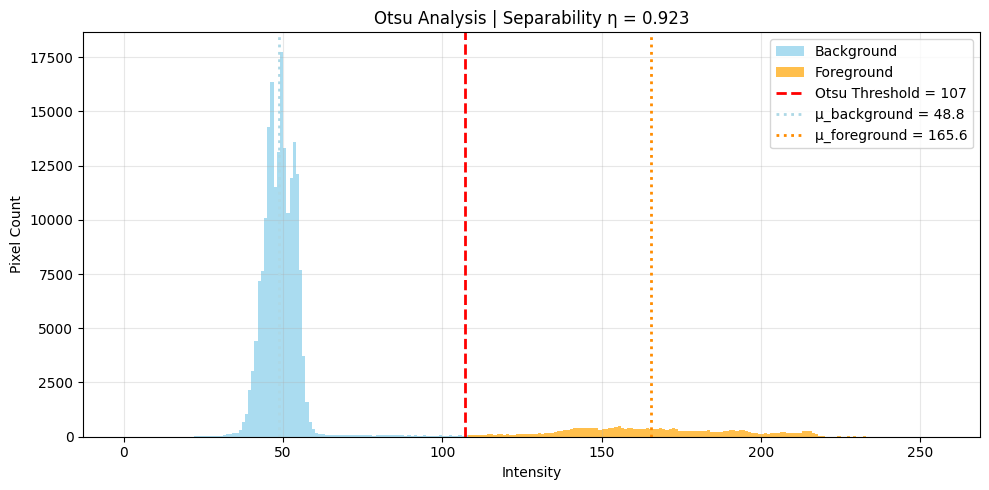

Otsu threshold: 107
Separability η: 0.9228


In [208]:
plot_otsu_analysis(img2, opt_th2)

This example demonstrates that Otsu thresholding performs very well when:

- The image has uniform illumination

- The background is homogeneous

- The intensity distributions of foreground and background are clearly separated

The high separability value confirms that the two classes are almost ideally separated in intensity space. Therefore, a single global threshold is sufficient for accurate segmentation.

Compared to more complex images (e.g., document images with shadows), this example highlights the strengths of global thresholding methods under favorable conditions.

Shape: (1000, 1500, 3)


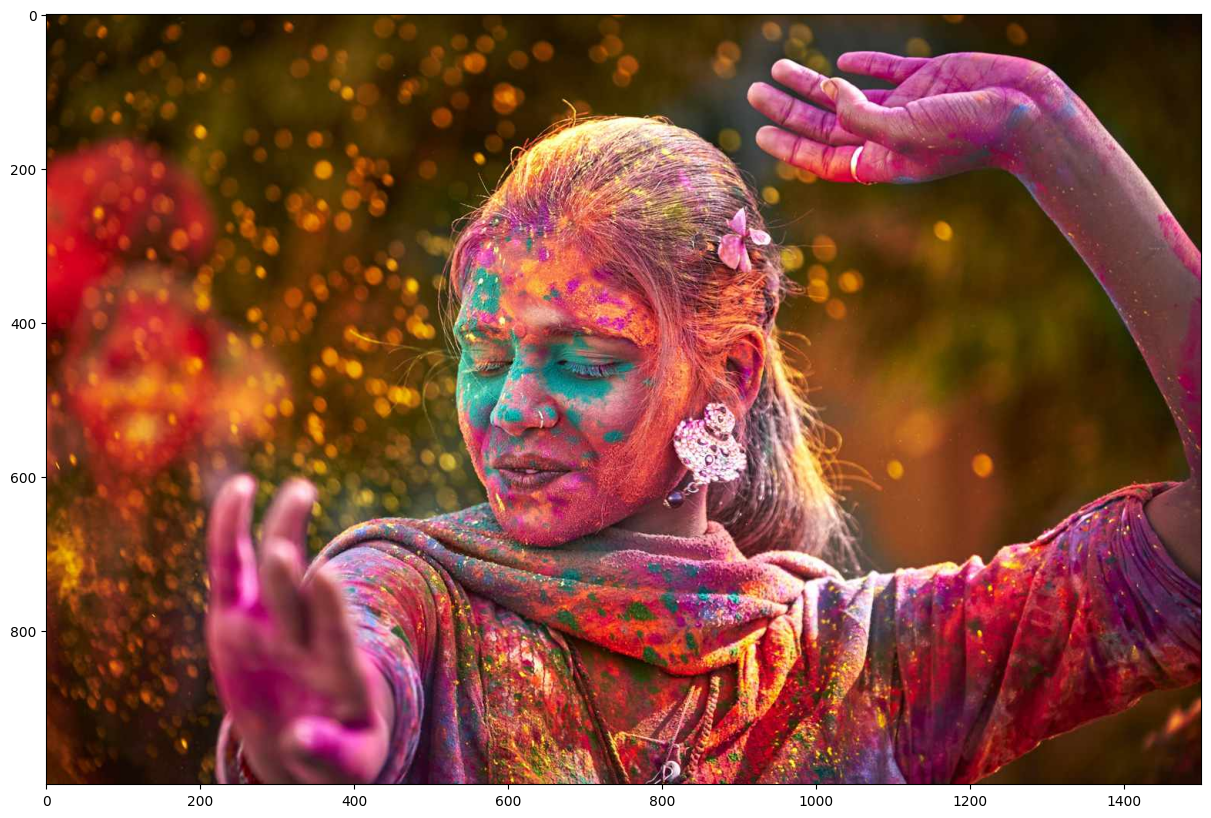

In [209]:
img3 = cv2.imread('data/11.jpg')
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
print(f'Shape: {img3_rgb.shape}')
plt.imshow(img3_rgb)

In [210]:
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

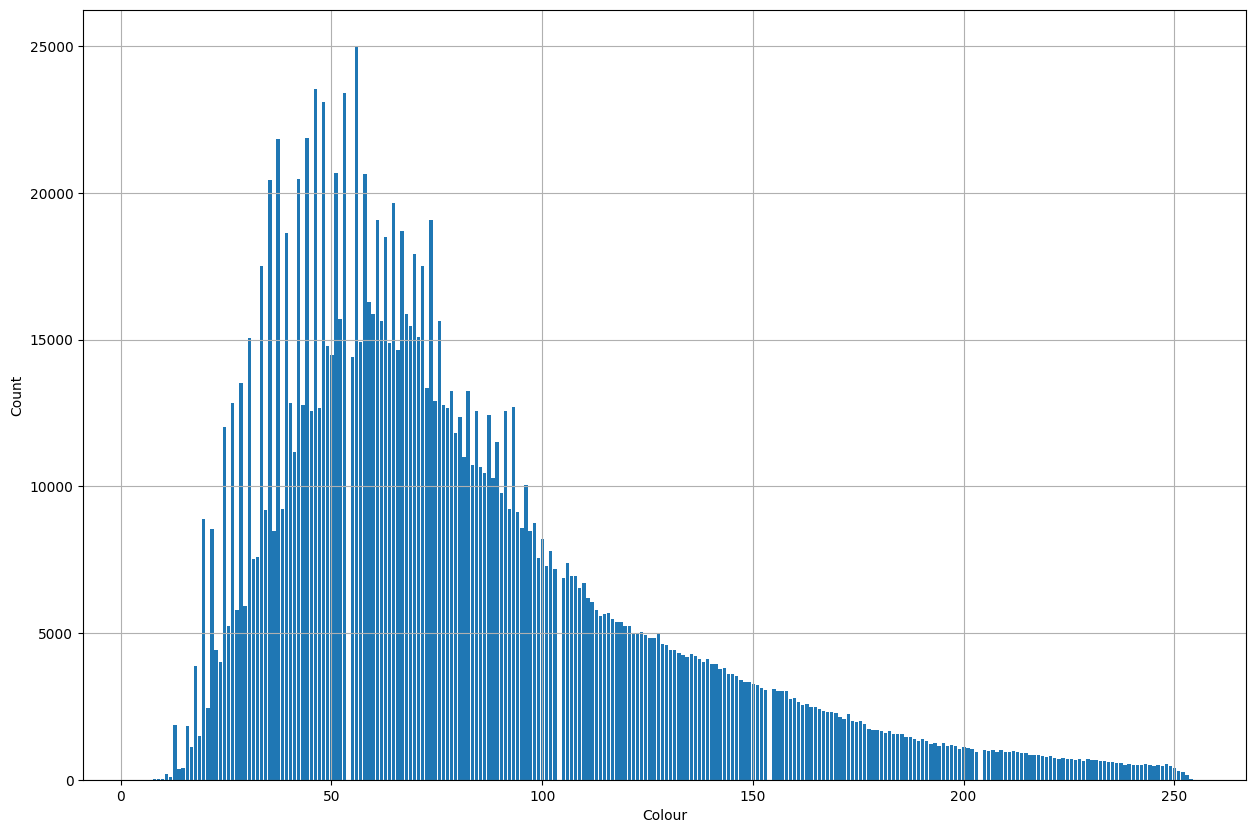

In [211]:
h = np.histogram(img3, 256)
plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour'), plt.ylabel('Count')
plt.grid(True)

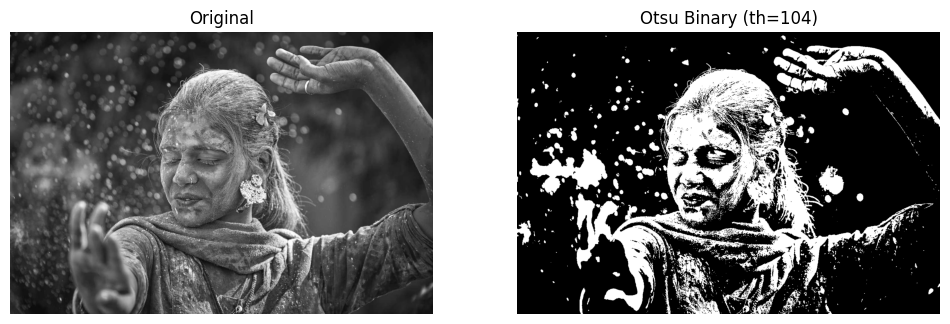

In [212]:
opt_th3, best_wcv3, binary3 = otsu_threshold_bruteforce(img3, return_binary=True)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(binary3, cmap="gray")
plt.title(f"Otsu Binary (th={opt_th3})")
plt.axis("off")
plt.show()

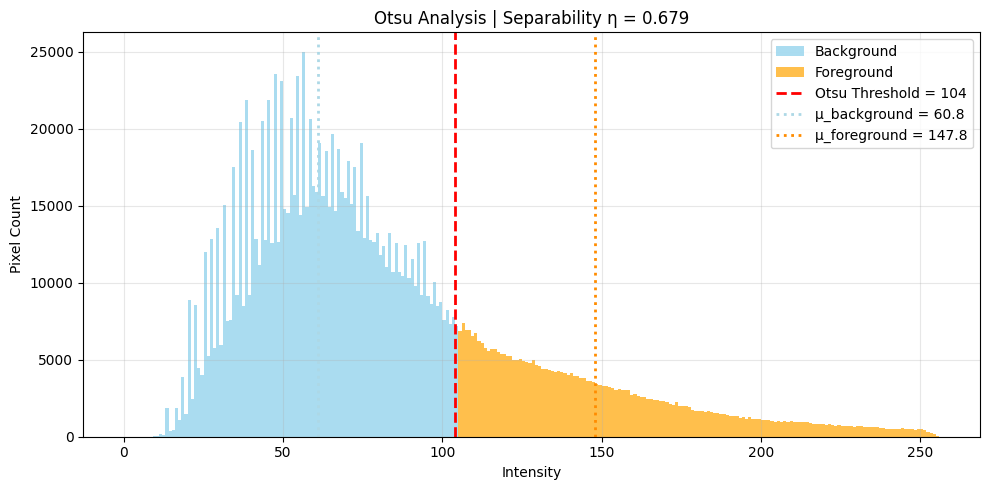

Otsu threshold: 104
Separability η: 0.6786


In [213]:
plot_otsu_analysis(img3, opt_th3)

The Otsu algorithm determined a global threshold of 104, with a separability measure η ≈ 0.68.

This value indicates moderate class separability. Unlike the banana example, the histogram does not exhibit a clear bimodal structure. Instead, the intensity distribution is wide and highly overlapping due to complex textures, shadows, highlights, and gradual illumination changes.

The resulting binary image preserves the main contours and overall structure of the scene. The subject remains clearly recognizable, and major edges are well emphasized.

However, the binarization removes:

- Gradual intensity transitions

- Fine tonal variations

- Soft shading and depth cues

As a result, the image loses grayscale information and appears high-contrast and fragmented in textured regions.

This example demonstrates that Otsu thresholding can still preserve structural information in complex natural images. However, because the scene does not consist of two clearly separated intensity classes, a single global threshold cannot maintain tonal detail.

# Practical Application of Otsu Thresholding in Document Analysis

Otsu thresholding is used as a preprocessing step to automatically segment the document from the background. The resulting binary mask restricts the Harris corner detection to the document region, improving robustness and reducing false corner responses from background areas.

In [214]:
def detect_document_corners(img):

    if img is None:
        raise ValueError("Input image is None.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray) / 255.0

    # ADDED: Gaussian smoothing to reduce small gradient noise before Harris
    gray = cv2.GaussianBlur(gray, (5,5), 0)

    rows, cols = gray.shape

    # ADDED: automatic document segmentation using Otsu thresholding
    gray_uint8 = (gray * 255).astype(np.uint8)
    _, mask = cv2.threshold(gray_uint8, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # ADDED: morphological closing to refine the document mask
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    cornerness = cv2.cornerHarris(gray, 2, 3, 0.04)
    cornerness = np.maximum(cornerness, 0)
    cornerness = np.log(cornerness + 1e-6)

    # CHANGED: adaptive threshold instead of fixed value (-7)
    threshold = np.percentile(cornerness, 99)

    # CHANGED: quadrant size scaled according to image resolution
    quad_size = int(0.01 * min(rows, cols))
    quad_size = max(5, min(quad_size, 25))

    th_top_left = -1e12
    th_top_right = -1e12
    th_bottom_left = -1e12
    th_bottom_right = -1e12

    opt_top_left = None
    opt_top_right = None
    opt_bottom_left = None
    opt_bottom_right = None

    for r in range(quad_size, rows - quad_size):
        for c in range(quad_size, cols - quad_size):

            # ADDED: restrict corner search to detected document region
            if mask[r, c] == 0:
                continue

            if cornerness[r, c] < threshold:
                continue

            block = gray[r-quad_size:r+quad_size+1,
                         c-quad_size:c+quad_size+1] * 255

            quad_top_left = block[0:quad_size, 0:quad_size]
            quad_top_right = block[0:quad_size, quad_size+1:2*quad_size+1]
            quad_bottom_left = block[quad_size+1:2*quad_size+1, 0:quad_size]
            quad_bottom_right = block[quad_size+1:2*quad_size+1, quad_size+1:2*quad_size+1]

            # Original quadrant-based descriptor retained
            descriptor = np.mean(quad_bottom_right) - \
                         np.mean(quad_top_left) - \
                         np.mean(quad_top_right) - \
                         np.mean(quad_bottom_left)
            if descriptor > th_top_left:
                th_top_left = descriptor
                opt_top_left = (c, r)

            descriptor = np.mean(quad_bottom_left) - \
                         np.mean(quad_top_left) - \
                         np.mean(quad_top_right) - \
                         np.mean(quad_bottom_right)
            if descriptor > th_top_right:
                th_top_right = descriptor
                opt_top_right = (c, r)

            descriptor = np.mean(quad_top_right) - \
                         np.mean(quad_top_left) - \
                         np.mean(quad_bottom_left) - \
                         np.mean(quad_bottom_right)
            if descriptor > th_bottom_left:
                th_bottom_left = descriptor
                opt_bottom_left = (c, r)

            descriptor = np.mean(quad_top_left) - \
                         np.mean(quad_top_right) - \
                         np.mean(quad_bottom_left) - \
                         np.mean(quad_bottom_right)
            if descriptor > th_bottom_right:
                th_bottom_right = descriptor
                opt_bottom_right = (c, r)

    return opt_top_left, opt_top_right, opt_bottom_left, opt_bottom_right


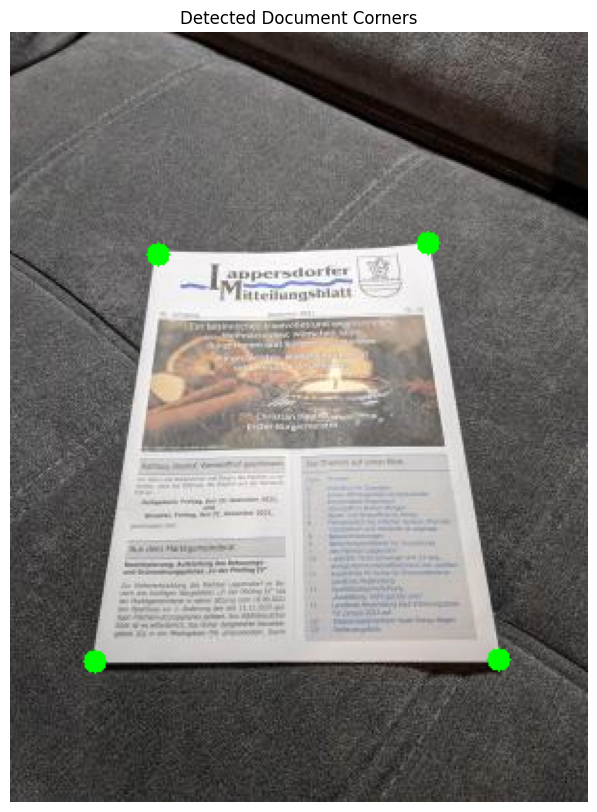

In [215]:
img = cv2.imread('data/document2.jpg')

corners = detect_document_corners(img)

out = img.copy()

for pt in corners:
    if pt is not None:
        out = cv2.circle(out, pt, 6, (0,255,0), -1)

out_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)

plt.imshow(out_rgb)
plt.title("Detected Document Corners")
plt.axis("off")
plt.show()